<a href="https://colab.research.google.com/github/zaccesss/DG1AID-Labs/blob/main/Week3/DG1AID_Lab_Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DG1AID – Lab sheet – Week 3**

**Python Solutions: Data Handling & Visualisation**

These are example solutions – as always with programming, equivalent correct approaches are possible.

**Task 0: Setup**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Task 1: Importing Data from Excel**

In [ ]:
df = pd.read_excel("student_scores.xlsx")
print(df.head())
print(df.columns)
print(df.shape)

   StudentID  Maths  Physics  Chemistry
0          1     81       32         71
1          2     44       30         36
2          3     90       34         45
3          4     50       43         89
4          5     53       56         31
Index(['StudentID', 'Maths', 'Physics', 'Chemistry'], dtype='object')
(100, 4)


**Extra thought**

You must provide the full or relative file path to the Excel file. (e.g., "C:/Users/username/Documents/student_scores.xlsx")

**Task 2: Importing Data as Vectors**

In [ ]:
maths_series = df['Maths']
maths_vector = df['Maths'].to_numpy()
manual_vector = np.array([12, 15, 18, 21, 24, 30])
print(type(maths_series), maths_series.shape)
print(type(maths_vector), maths_vector.shape)
print(type(manual_vector), manual_vector.shape)

<class 'pandas.core.series.Series'> (100,)
<class 'numpy.ndarray'> (100,)
<class 'numpy.ndarray'> (6,)


**Task 3: Importing Data as Matrices**

In [ ]:
scores_matrix = df[['Maths', 'Physics', 'Chemistry']].to_numpy()
print(scores_matrix.shape)
manual_matrix = np.array([[1, 2, 3],
                          [4, 5, 6],
                          [7, 8, 9]])

(100, 3)


**Task 4: Extracting Vectors from Matrices**

In [ ]:
first_column = scores_matrix[:, 0]
second_row = scores_matrix[1, :]
physics_scores = scores_matrix[:, 1]
print(second_row)

[44 30 36]


**Extra challenge**

Column-wise extraction uses : for rows; row-wise extraction uses : for columns.

**Task 5: Statistics on Vectors**

In [ ]:
mean_val = np.mean(maths_vector)
median_val = np.median(maths_vector)
from scipy import stats
mode_stats = stats.mode(maths_vector, keepdims=True)
mode_val = mode_stats[0]
mode_count = mode_stats[1]
range_val = np.max(maths_vector) - np.min(maths_vector)
q1 = np.percentile(maths_vector, 25)
q3 = np.percentile(maths_vector, 75)
iqr_val = q3 - q1
variance_val = np.var(maths_vector)
std_val = np.std(maths_vector)
print("Maths mean:", mean_val)
print("Maths median:", median_val)
print("Maths mode stats:", mode_stats)
print("Maths mode value:", mode_val)
print("Maths mode count:", mode_count)
print("Maths range:", range_val)
print("Maths IQR:", iqr_val)
print("Maths variance:", variance_val)
print("Maths standard deviation:", std_val)

Maths mean: 64.18
Maths median: 64.5
Maths mode stats: ModeResult(mode=array([91]), count=array([6]))
Maths mode value: [91]
Maths mode count: [6]
Maths range: 70
Maths IQR: 38.25
Maths variance: 444.9675999999999
Maths standard deviation: 21.094255142099705


**Extra challenge**

Standard deviation measures how spread out the data is around the mean.

**Task 6: Statistics on Matrices**

In [ ]:
overall_mean = np.mean(scores_matrix)
column_means = np.mean(scores_matrix, axis=0)
column_medians = np.median(scores_matrix, axis=0)
column_std = np.std(scores_matrix, axis=0)
chemistry = scores_matrix[:, 2]
chem_range = np.max(chemistry) - np.min(chemistry)
chem_iqr = np.percentile(chemistry, 75) - np.percentile(chemistry, 25)
print("Overall mean:", overall_mean)
print("Column means:", column_means)
print("Column medians:", column_medians)
print("Column standard deviation:", column_std)
print("Chemistry range:", chem_range)
print("Chemistry IQR:", chem_iqr)

Overall mean: 64.47
Column means: [64.18 64.85 64.38]
Column medians: [64.5 65.  62. ]
Column standard deviation: [21.09425514 22.14650085 18.75088265]
Chemistry range: 68
Chemistry IQR: 27.25


**Extra challenge**

axis=0 calculates statistics down columns; axis=1 works across rows.

**Task 7: Generating Charts from Vectors**

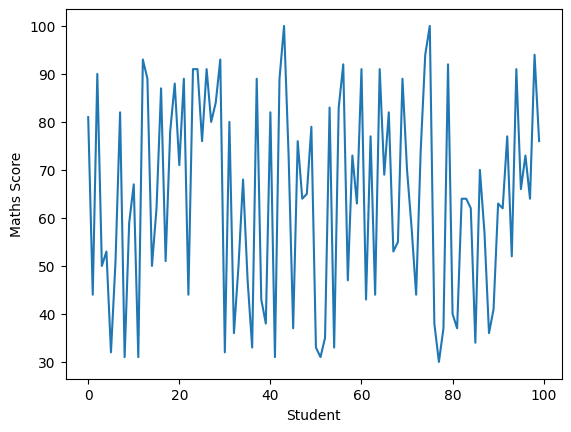

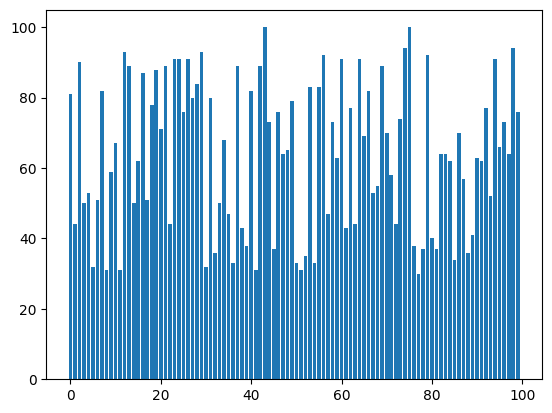

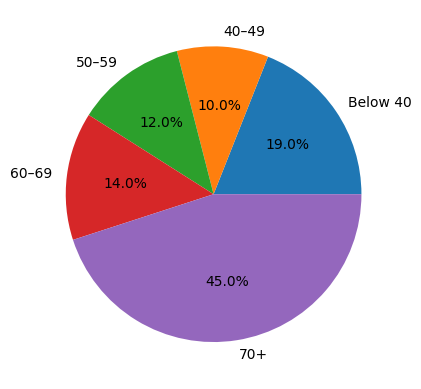

In [ ]:
plt.plot(maths_vector)
plt.xlabel("Student")
plt.ylabel("Maths Score")
plt.show()
plt.bar(range(len(maths_vector)), maths_vector)
plt.show()
bins = [0, 40, 50, 60, 70, 100]
counts = [np.sum(maths_vector < 40),
          np.sum((maths_vector >= 40) & (maths_vector < 50)),
          np.sum((maths_vector >= 50) & (maths_vector < 60)),
          np.sum((maths_vector >= 60) & (maths_vector < 70)),
          np.sum(maths_vector >= 70)]

plt.pie(counts, labels=["Below 40", "40–49", "50–59", "60–69", "70+"], autopct="%1.1f%%")
plt.show()

**Task 8: Generating Charts from Matrices**

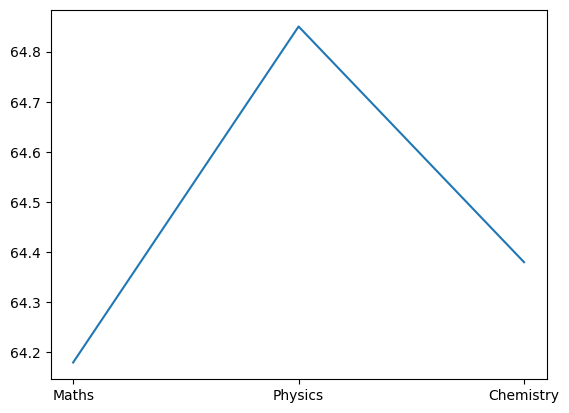

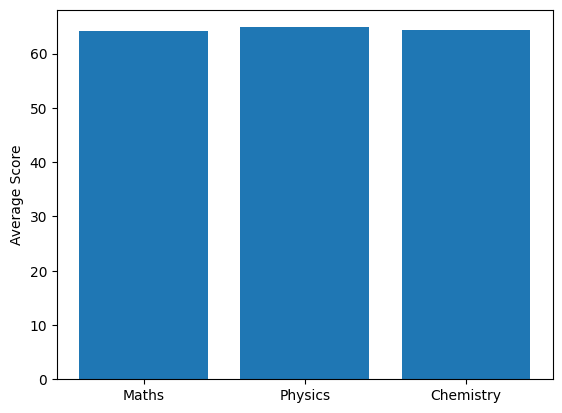

In [ ]:
subject_means = np.mean(scores_matrix, axis=0)
subjects = ['Maths', 'Physics', 'Chemistry']

plt.plot(subjects, subject_means)
plt.show()
plt.bar(subjects, subject_means)
plt.ylabel("Average Score")
plt.show()

**Example for graph of choice**

A boxplot could be utilised here to show score spread for each subject.

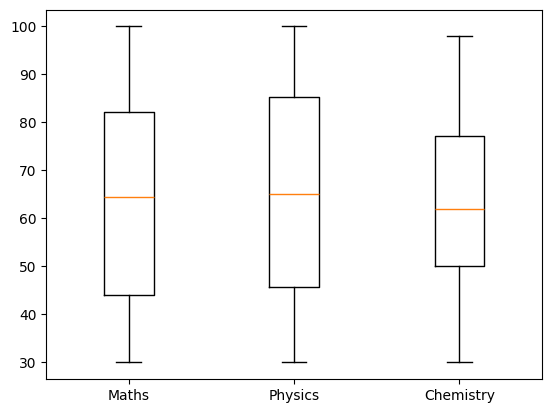

In [ ]:
plt.boxplot(scores_matrix, tick_labels=subjects)
plt.show()

**Task 9: Reflection**

*   Vectors are simpler for single-variable analysis; matrices are better for comparing datasets.
*   NumPy and Pandas reduce code complexity and improve reliability.
*   These skills are essential for analysing experimental, financial, or survey data.

Vectors were easier to work with for single-variable analysis such as extracting and calculating statistics on one subject at a time. Matrices are more powerful when comparing multiple variables together, such as analysing Maths, Physics and Chemistry scores side by side, but require more careful indexing to extract the right rows and columns.
NumPy and Pandas significantly reduce the amount of code needed to handle and analyse data. Without these libraries, tasks like calculating the mean, median and standard deviation would require writing loops manually. These libraries also handle large datasets efficiently and reliably, reducing the chance of errors.
These techniques are directly relevant to Electronic Engineering and Computer Science. In hardware projects, data from sensors and measurements can be stored as vectors and analysed statistically. In software and AI projects, datasets are almost always represented as matrices and processed using exactly these tools. Understanding how to import, manipulate and visualise data is a fundamental skill across the entire degree programme.